### Extra featrues that we could create
avrage number of rounds per fight, maybe diff

* Physical advantage – reach + height − age (taller, longer, fresher).
* Striking pressure – sig-strike differential weighted toward the more active fighter.
* Grappling pressure – takedowns and sub attempts, where the difference is the threat, not the points.
* Experience gap – difference in total rounds + title bouts. A fighter who's been in five-round wars 8 times has a different gas tank than someone with 6 prelim minutes.
* Finish tendency – career KO + sub rate. Guys who finish create variance.
* Stance matchup – categorical, because Orthodox vs Southpaw is structurally different from Orthodox vs Orthodox.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

csv_path = Path.cwd().parent / "data" / "all_fights.csv"
data_frame = pd.read_csv(csv_path)


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]

# extra features list
extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", "blue_age", "fight_date"
]


# ===================================== CREATING NEW FEATURES
print("===============")

#print(data_frame['stance_diff'].unique())

# total number of fights 
data_frame["red_total_fights"] = (data_frame["red_wins"] + data_frame["red_losses"])
data_frame["blue_total_fights"] = (data_frame["blue_wins"] + data_frame["blue_losses"])


# red_avg_number_rounds_per_fight
data_frame["red_avg_number_rounds_per_fight"] = round((data_frame["red_total_fights"]) / data_frame["red_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["red_avg_number_rounds_per_fight"] > 0) & (data_frame["red_avg_number_rounds_per_fight"] < 6)]
extra_features.append("red_avg_number_rounds_per_fight")

# blue_avg_number_rounds_per_fight
data_frame["blue_avg_number_rounds_per_fight"] = round((data_frame["blue_total_fights"]) / data_frame["blue_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["blue_avg_number_rounds_per_fight"] > 0) & (data_frame["blue_avg_number_rounds_per_fight"] < 6)]
extra_features.append("blue_avg_number_rounds_per_fight")

# diff_avg_rounds
data_frame["avg_rounds_diff"] = round(data_frame["red_avg_number_rounds_per_fight"] - data_frame["blue_avg_number_rounds_per_fight"], 2)



# Physical advantage – reach + height − age (taller, longer, fresher).
# blue_height_cms
# blue_reach_cms
# blue_age

# 
data_frame["red_physical_advantage"] = round(data_frame["red_height_cms"] + data_frame["red_reach_cms"] + data_frame["red_age"], 2)
#
data_frame["blue_physical_advantage"] = round(data_frame["blue_height_cms"] + data_frame["blue_reach_cms"] + data_frame["blue_age"], 2)
# 
data_frame["physical_advantage_diff"] = round(data_frame["red_physical_advantage"] + data_frame["blue_physical_advantage"], 2)

#print(test_frame.loc[1]["red_avg_number_rounds_per_fight"])
#print(test_frame['red_avg_number_rounds_per_fight'].unique())

print("===============")
#NOTE: extra  features
# - red_avg_number_rounds_per_fight
# - blue_avg_number_rounds_per_fight
# ===================================== CREATING NEW FEATURES


# getting all features with diff 
diff_features_df = data_frame.filter(regex=r'_diff')

#TODO: Other attributes than diff that we will keep
extra_features_df = data_frame[extra_features]

feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)

#NOTE: maybe no buckets
# adding age buckets
bins = [17, 23, 27, 33, float("inf")]
labels = ["18-23", "24-27", "28-33", "34+"]

feature_selected_df["red_age_bucket"] = pd.cut(
    data_frame["red_age"],
    bins=bins,
    labels=labels
)

feature_selected_df["blue_age_bucket"] = pd.cut(
    data_frame["blue_age"],
    bins=bins,
    labels=labels
)


# drop red_ and blue_age
feature_selected_df = feature_selected_df.drop(columns=['red_age'])
feature_selected_df = feature_selected_df.drop(columns=['blue_age'])
# drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=['odds_diff'])

# ============================================================================================== SPLIT
#NOTE: class variable??
class_df = data_frame[["red_winner","fight_date"]]


#NOTE: split the data based on fight date
DATE = "2023-06-01"
SPLIT_DATE = r"2023-06-01"

# splitting the data thing
x_train_OG = feature_selected_df.loc[feature_selected_df['fight_date'] <= SPLIT_DATE]
x_test_OG  = feature_selected_df.loc[feature_selected_df['fight_date'] > SPLIT_DATE]

# drop fight_date
x_train_OG = x_train_OG.drop(columns=['fight_date'])
x_test_OG = x_test_OG.drop(columns=['fight_date'])

# splitting the class thing
y_train_OG = class_df.loc[class_df['fight_date'] <= SPLIT_DATE]
y_test_OG  = class_df.loc[class_df['fight_date'] > SPLIT_DATE]

# drop fight_date
y_train_OG = y_train_OG.drop(columns=['fight_date'])
y_test_OG = y_test_OG.drop(columns=['fight_date'])

#x_train.info()

In [2]:
# / "data" / "all_fights.csv"
data_frame = pd.read_csv(csv_path)


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]

# extra features list
extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", "blue_age", "fight_date"
]


# ===================================== CREATING NEW FEATURES
print("===============")

#print(data_frame['stance_diff'].unique())

# total number of fights 
data_frame["red_total_fights"] = (data_frame["red_wins"] + data_frame["red_losses"])
data_frame["blue_total_fights"] = (data_frame["blue_wins"] + data_frame["blue_losses"])


# red_avg_number_rounds_per_fight
data_frame["red_avg_number_rounds_per_fight"] = round((data_frame["red_total_fights"]) / data_frame["red_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["red_avg_number_rounds_per_fight"] > 0) & (data_frame["red_avg_number_rounds_per_fight"] < 6)]
extra_features.append("red_avg_number_rounds_per_fight")

# blue_avg_number_rounds_per_fight
data_frame["blue_avg_number_rounds_per_fight"] = round((data_frame["blue_total_fights"]) / data_frame["blue_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["blue_avg_number_rounds_per_fight"] > 0) & (data_frame["blue_avg_number_rounds_per_fight"] < 6)]
extra_features.append("blue_avg_number_rounds_per_fight")

# diff_avg_rounds
data_frame["avg_rounds_diff"] = round(data_frame["red_avg_number_rounds_per_fight"] - data_frame["blue_avg_number_rounds_per_fight"], 2)



# Physical advantage – reach + height − age (taller, longer, fresher).
# blue_height_cms
# blue_reach_cms
# blue_age

# 
data_frame["red_physical_advantage"] = round(data_frame["red_height_cms"] + data_frame["red_reach_cms"] + data_frame["red_age"], 2)
#
data_frame["blue_physical_advantage"] = round(data_frame["blue_height_cms"] + data_frame["blue_reach_cms"] + data_frame["blue_age"], 2)
# 
data_frame["physical_advantage_diff"] = round(data_frame["red_physical_advantage"] + data_frame["blue_physical_advantage"], 2)

#print(test_frame.loc[1]["red_avg_number_rounds_per_fight"])
#print(test_frame['red_avg_number_rounds_per_fight'].unique())

print("===============")
#NOTE: extra  features
# - red_avg_number_rounds_per_fight
# - blue_avg_number_rounds_per_fight
# ===================================== CREATING NEW FEATURES


# getting all features with diff 
diff_features_df = data_frame.filter(regex=r'_diff')

#TODO: Other attributes than diff that we will keep
extra_features_df = data_frame[extra_features]

feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)

#NOTE: maybe no buckets
# adding age buckets
bins = [17, 23, 27, 33, float("inf")]
labels = ["18-23", "24-27", "28-33", "34+"]

feature_selected_df["red_age_bucket"] = pd.cut(
    data_frame["red_age"],
    bins=bins,
    labels=labels
)

feature_selected_df["blue_age_bucket"] = pd.cut(
    data_frame["blue_age"],
    bins=bins,
    labels=labels
)


# drop red_ and blue_age
feature_selected_df = feature_selected_df.drop(columns=['red_age'])
feature_selected_df = feature_selected_df.drop(columns=['blue_age'])
# drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=['odds_diff'])

# ============================================================================================== SPLIT
#NOTE: class variable??
class_df = data_frame[["red_winner","fight_date"]]


#NOTE: split the data based on fight date
DATE = "2023-06-01"
SPLIT_DATE = r"2023-06-01"

# splitting the data thing
x_train_OG = feature_selected_df.loc[feature_selected_df['fight_date'] <= SPLIT_DATE]
x_test_OG  = feature_selected_df.loc[feature_selected_df['fight_date'] > SPLIT_DATE]

# drop fight_date
x_train_OG = x_train_OG.drop(columns=['fight_date'])
x_test_OG = x_test_OG.drop(columns=['fight_date'])

# splitting the class thing
y_train_OG = class_df.loc[class_df['fight_date'] <= SPLIT_DATE]
y_test_OG  = class_df.loc[class_df['fight_date'] > SPLIT_DATE]

# drop fight_date
y_train_OG = y_train_OG.drop(columns=['fight_date'])
y_test_OG = y_test_OG.drop(columns=['fight_date'])

#x_train.info()

# XGBoost

Best parameters:
{'clf__colsample_bytree': 0.5, 'clf__gamma': 3, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__min_child_weight': 10, 'clf__n_estimators': 300, 'clf__subsample': 0.3}

Best cross-validation ROC-AUC:
0.6328088085865089
Training score: 0.6853599646963666
Validation score: 0.6328088085865089

0.6078853046594982
              precision    recall  f1-score   support

           0       0.61      0.34      0.44       623
           1       0.61      0.83      0.70       772

    accuracy                           0.61      1395
   macro avg       0.61      0.58      0.57      1395
weighted avg       0.61      0.61      0.58      1395

================== Feature Importance ==================
                                feature  importance
2                         num__age_diff    0.051311
41              cat__red_age_bucket_34+    0.038459
4                      num__losses_diff    0.034831
43           cat__blue_age_bucket_24-27    0.033366
0                    

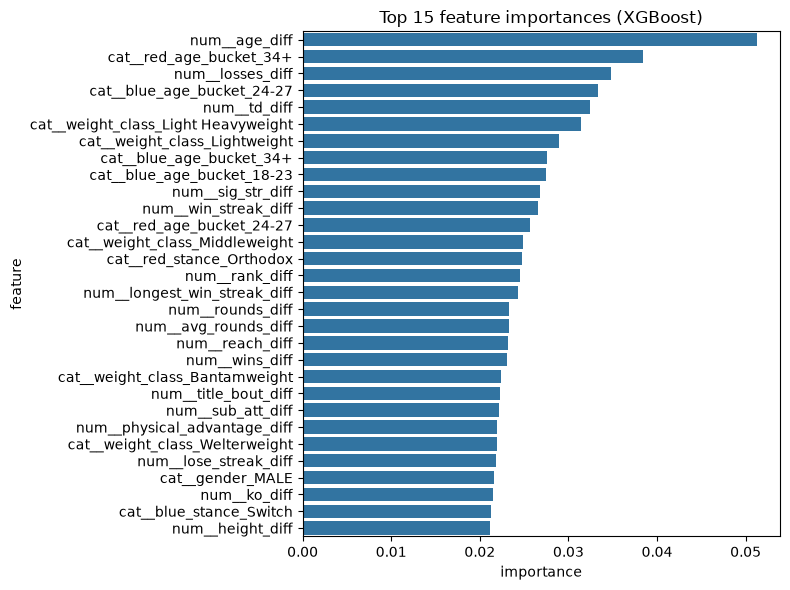

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report


x_train = x_train_OG
x_test = x_test_OG


le = LabelEncoder()
y_train = le.fit_transform(y_train_OG["red_winner"])
y_test = le.transform(y_test_OG["red_winner"])


#NOTE: always need to add new features here
categorical_features = [
    "red_stance", "blue_stance", "weight_class",
    "gender", "red_age_bucket", "blue_age_bucket"
]

numeric_features = [
    "td_diff", "sig_str_diff", "age_diff",
    "reach_diff", "losses_diff", "sub_att_diff",
    "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff",
    "rounds_diff", "height_diff", "ko_diff",
    "submission_diff", "avg_rounds_diff", "physical_advantage_diff"
]

# num: fill missing values with the median
# cat: fill categorical colomns with the most common category
# one-hot encode: turns features like orthodox/southpaw into -
# separeate 0/1 columns, since models cant use text directly.
# ColumnTransformer: applies the right treatment to the right -
# columns automatically.
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])


pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

pipeline_xgb.fit(x_train, y_train)
y_predicted = pipeline_xgb.predict(x_test)

# XGBOOST hyper parameters
param_grid = {
    "clf__n_estimators": [300, 500], # number of trees to build
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.3, 0.5],
    "clf__colsample_bytree": [0.5],
    "clf__min_child_weight": [10, 20],
    "clf__gamma": [0, 3, 5],
}


grid_search_xg = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_search_xg.fit(x_train, y_train)


print("Best parameters:")
print(grid_search_xg.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_xg.best_score_)

best_index = grid_search_xg.best_index_
print("Training score:", grid_search_xg.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_xg.cv_results_["mean_test_score"][best_index])


best_model = grid_search_xg.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

preds = best_model.predict(x_test)

print()
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print("================== Feature Importance ==================")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(30), x="importance", y="feature")
plt.title("Top 15 feature importances (XGBoost)")
plt.tight_layout()
plt.show()

# CatBoost

Best parameters:
{'clf__depth': 4, 'clf__iterations': 500, 'clf__l2_leaf_reg': 10, 'clf__learning_rate': 0.01, 'clf__subsample': 0.5}

Best cross-validation ROC-AUC:
0.6281575245124753
Training score: 0.6825933482596064
Validation score: 0.6281575245124753

0.6
              precision    recall  f1-score   support

           0       0.59      0.33      0.42       623
           1       0.60      0.82      0.69       772

    accuracy                           0.60      1395
   macro avg       0.60      0.57      0.56      1395
weighted avg       0.60      0.60      0.57      1395

================== Feature Importance ==================
                    feature  importance
0                  age_diff   29.285333
1                   td_diff   13.313113
2              sig_str_diff    7.665021
4               losses_diff    6.316291
23          blue_age_bucket    4.680965
22           red_age_bucket    4.578309
7           win_streak_diff    4.430769
18               red_stance    3.4

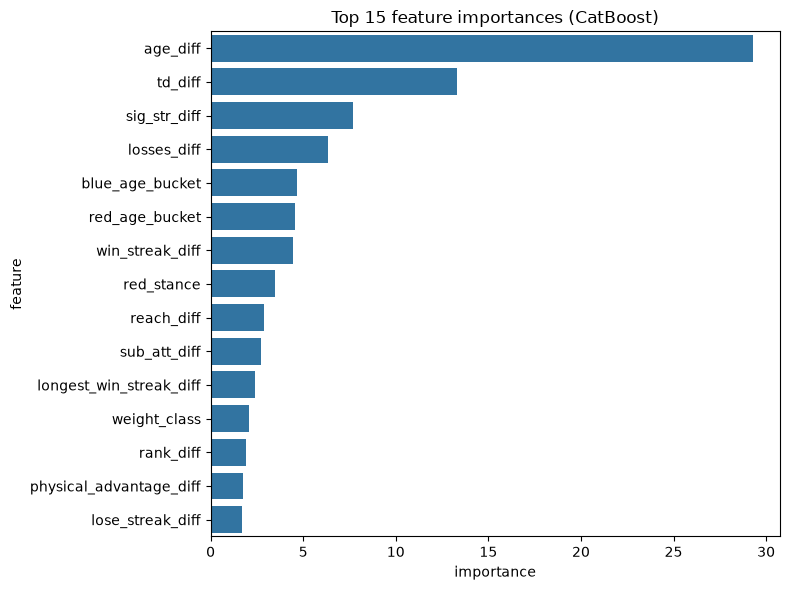

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from catboost import CatBoostClassifier

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
x_train = x_train_OG
x_test = x_test_OG

le = LabelEncoder()
y_train = le.fit_transform(y_train_OG["red_winner"])
y_test = le.transform(y_test_OG["red_winner"])

# NOTE: always need to add new features here
categorical_features = [
    "red_stance", "blue_stance", "weight_class",
    "gender", "red_age_bucket", "blue_age_bucket"
]

numeric_features = [
    "age_diff", "td_diff", "sig_str_diff",
    "reach_diff", "losses_diff", "sub_att_diff",
    "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff",
    "rounds_diff", "height_diff", "ko_diff",
    "submission_diff", "avg_rounds_diff", "physical_advantage_diff"
]

# ---------------------------------------------------------
# 2. Preprocessing — impute only, CatBoost handles categoricals natively
# ---------------------------------------------------------
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", SimpleImputer(strategy="most_frequent"), categorical_features)
])

# Numeric columns come first, categorical columns second — this order
# is fixed by the ColumnTransformer above, so these indices stay valid
# across every CV fold.
cat_feature_indices = list(
    range(len(numeric_features), len(numeric_features) + len(categorical_features))
)

pipeline_cat = Pipeline([
    ("preprocess", preprocessor),
    ("clf", CatBoostClassifier(
        eval_metric="Logloss",
        random_state=42,
        verbose=0
        # cat_features is NOT passed here — passed at fit time instead,
        # to avoid the sklearn clone() RuntimeError
    ))
])

# ---------------------------------------------------------
# 3. Hyperparameter grid
# ---------------------------------------------------------
param_grid = {
    "clf__iterations": [300, 500],
    "clf__depth": [4, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__l2_leaf_reg": [3, 10],
    "clf__subsample": [0.5, 0.8],
}

grid_search_cb = GridSearchCV(
    pipeline_cat,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

# route cat_features to the "clf" step's .fit() call
grid_search_cb.fit(x_train, y_train, clf__cat_features=cat_feature_indices)

# ---------------------------------------------------------
# 4. Cross-validation results
# ---------------------------------------------------------
print("Best parameters:")
print(grid_search_cb.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_cb.best_score_)

best_index = grid_search_cb.best_index_
print("Training score:", grid_search_cb.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_cb.cv_results_["mean_test_score"][best_index])

# ---------------------------------------------------------
# 5. Final held-out test evaluation
# ---------------------------------------------------------
best_model = grid_search_cb.best_estimator_
cat_clf = best_model.named_steps["clf"]

preds = best_model.predict(x_test)

print()
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

# ---------------------------------------------------------
# 6. Feature importance
# ---------------------------------------------------------
feature_names = numeric_features + categorical_features
importances = cat_clf.get_feature_importance()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("================== Feature Importance ==================")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances (CatBoost)")
plt.tight_layout()
plt.show() 

# Logistic

/home/kormakur-snorrason/HR/Year3/Fall/MachineLearning/MachineLearningRepo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kormakur-snorrason/HR/Year3/Fall/MachineLearning/MachineLearningRepo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/kormakur-snorrason/HR/Year3/Fall/MachineLearning/MachineLearningRepo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was depreca

Best parameters:
{'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}

Best cross-validation ROC-AUC:
0.6327823714807465
Training score: 0.6456644546759763
Validation score: 0.6327823714807465

0.6150537634408603
              precision    recall  f1-score   support

           0       0.61      0.40      0.48       623
           1       0.62      0.79      0.69       772

    accuracy                           0.62      1395
   macro avg       0.61      0.59      0.59      1395
weighted avg       0.61      0.62      0.60      1395

================== Coefficients (by |magnitude|) ==================
                            feature  coefficient
2                     num__age_diff    -0.335820
0                      num__td_diff    -0.194740
19         cat__red_stance_Southpaw     0.151329
7              num__win_streak_diff     0.100748
4                  num__losses_diff    -0.092665
6                    num__rank_diff    -0.089051
3                   num__reach_diff 

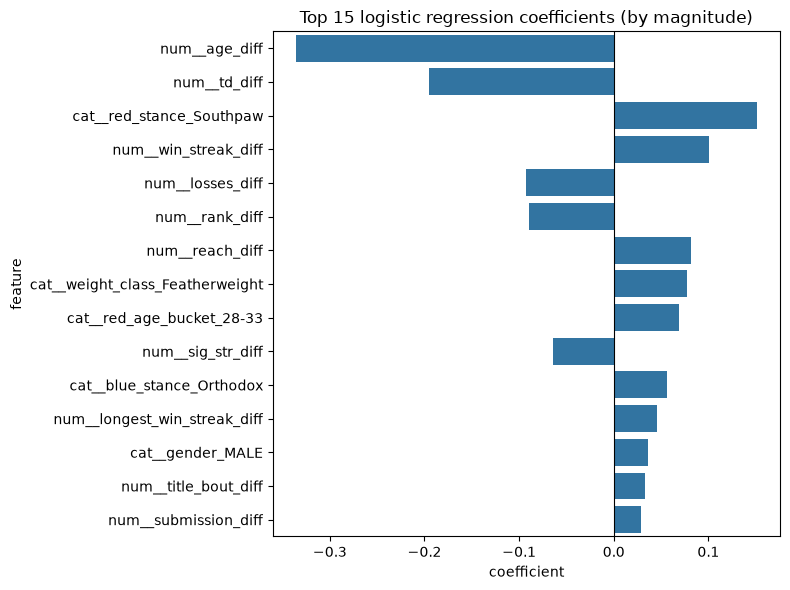

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
x_train = x_train_OG
x_test = x_test_OG

le = LabelEncoder()
y_train = le.fit_transform(y_train_OG["red_winner"])
y_test = le.transform(y_test_OG["red_winner"])

# NOTE: always need to add new features here
categorical_features = [
    "red_stance", "blue_stance", "weight_class",
    "gender", "red_age_bucket", "blue_age_bucket"
]

numeric_features = [
    "td_diff", "sig_str_diff", "age_diff",
    "reach_diff", "losses_diff", "sub_att_diff",
    "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff",
    "rounds_diff", "height_diff", "ko_diff",
    "submission_diff", "avg_rounds_diff", "physical_advantage_diff"
]

# ---------------------------------------------------------
# 2. Preprocessing — LR needs scaled numeric features (unlike XGBoost/CatBoost)
# ---------------------------------------------------------
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_lr = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(x_train, y_train)
y_predicted = pipeline_lr.predict(x_test)

# LOGISTIC REGRESSION hyperparameters
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],   # inverse of regularization strength — lower = stronger regularization
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"]         # supports both l1 and l2 penalties
}

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_search_lr.fit(x_train, y_train)

print("Best parameters:")
print(grid_search_lr.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_lr.best_score_)

best_index = grid_search_lr.best_index_
print("Training score:", grid_search_lr.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_lr.cv_results_["mean_test_score"][best_index])

best_model_lr = grid_search_lr.best_estimator_
lr_clf = best_model_lr.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model_lr.named_steps["preprocess"].get_feature_names_out()

# LR importance = coefficients, not feature_importances_ — sign matters here (direction of effect)
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_clf.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

preds = best_model_lr.predict(x_test)

print()
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print("================== Coefficients (by |magnitude|) ==================")
print(coef_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df.head(15), x="coefficient", y="feature")
plt.title("Top 15 logistic regression coefficients (by magnitude)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()



# Random forest

Best parameters:
{'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300}

Best cross-validation ROC-AUC:
0.6278864950499408
Training score: 0.8372304297786115
Validation score: 0.6278864950499408

0.5992831541218638
              precision    recall  f1-score   support

           0       0.59      0.32      0.42       623
           1       0.60      0.82      0.69       772

    accuracy                           0.60      1395
   macro avg       0.60      0.57      0.56      1395
weighted avg       0.60      0.60      0.57      1395

================== Feature Importance ==================
                         feature  importance
2                  num__age_diff    0.128836
0                   num__td_diff    0.091761
1              num__sig_str_diff    0.077168
17  num__physical_advantage_diff    0.058494
4               num__losses_diff    0.057124
12              num__rounds_diff    0.052578
5              num__sub_att_diff  

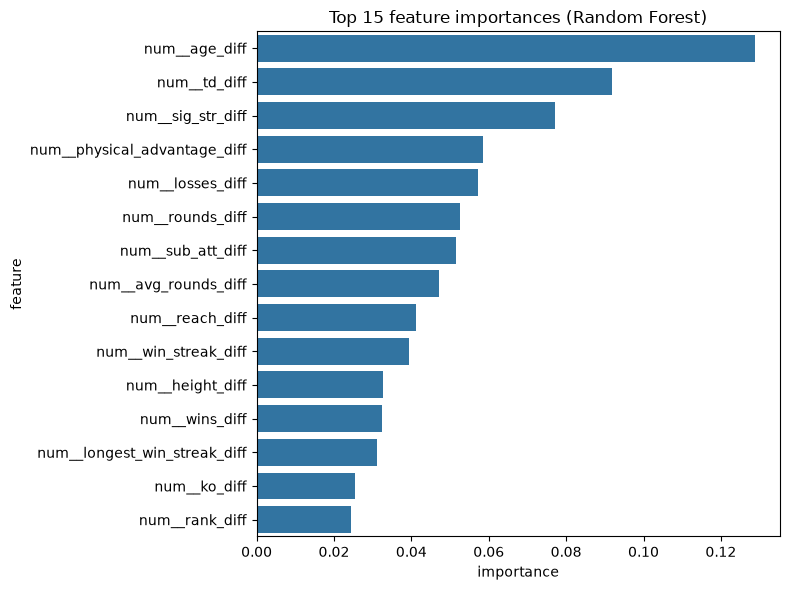

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
x_train = x_train_OG
x_test = x_test_OG

le = LabelEncoder()
y_train = le.fit_transform(y_train_OG["red_winner"])
y_test = le.transform(y_test_OG["red_winner"])

# NOTE: always need to add new features here
categorical_features = [
    "red_stance", "blue_stance", "weight_class",
    "gender", "red_age_bucket", "blue_age_bucket"
]

numeric_features = [
    "td_diff", "sig_str_diff", "age_diff",
    "reach_diff", "losses_diff", "sub_att_diff",
    "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff",
    "rounds_diff", "height_diff", "ko_diff",
    "submission_diff", "avg_rounds_diff", "physical_advantage_diff"
]

# ---------------------------------------------------------
# 2. Preprocessing — no scaling needed, trees are scale-invariant
# ---------------------------------------------------------
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(x_train, y_train)
y_predicted = pipeline_rf.predict(x_test)

# RANDOM FOREST hyperparameters
param_grid_rf = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", "log2"]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(x_train, y_train)

print("Best parameters:")
print(grid_search_rf.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_rf.best_score_)

best_index = grid_search_rf.best_index_
print("Training score:", grid_search_rf.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_rf.cv_results_["mean_test_score"][best_index])

best_model_rf = grid_search_rf.best_estimator_
rf_clf = best_model_rf.named_steps["clf"]

feature_names = best_model_rf.named_steps["preprocess"].get_feature_names_out()

importances = rf_clf.feature_importances_
importance_df_rf = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

preds = best_model_rf.predict(x_test)

print()
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print("================== Feature Importance ==================")
print(importance_df_rf.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df_rf.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances (Random Forest)")
plt.tight_layout()
plt.show()

# DATA STUFF

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    RocCurveDisplay
)

# ============================================================
# Register whichever grid searches you've actually run.
# ============================================================
fitted_models = {
    "XGBoost": grid_search_xg,
    "CatBoost": grid_search_cb,
    "Logistic Regression": grid_search_lr,
    "Random Forest": grid_search_rf,
    # "kNN": grid_search_knn,
}

# ============================================================
# 1. Model comparison table
# ============================================================
def summarize_model(name, gs, x_test, y_test):
    best_model = gs.best_estimator_
    preds = best_model.predict(x_test)
    probs = best_model.predict_proba(x_test)[:, 1]
    best_idx = gs.best_index_
    return {
        "model": name,
        "best_cv_roc_auc": gs.best_score_,
        "train_score_at_best": gs.cv_results_["mean_train_score"][best_idx],
        "val_score_at_best": gs.cv_results_["mean_test_score"][best_idx],
        "test_accuracy": accuracy_score(y_test, preds),
        "test_roc_auc": roc_auc_score(y_test, probs),
        "test_f1": f1_score(y_test, preds),
        "test_precision": precision_score(y_test, preds),
        "test_recall": recall_score(y_test, preds),
    }

results_table = pd.DataFrame([
    summarize_model(name, gs, x_test, y_test) for name, gs in fitted_models.items()
]).sort_values("test_roc_auc", ascending=False)

print("================== Model comparison ==================")
print(results_table.to_string(index=False))
print()

# ============================================================
# 2. Hyperparameter sensitivity — one boxplot per (model, param)
# ============================================================
for model_name, param_list in hyperparams_to_plot.items():
    if model_name not in fitted_models:
        continue
    gs = fitted_models[model_name]
    cv_df = pd.DataFrame(gs.cv_results_)

    fig, axes = plt.subplots(1, len(param_list), figsize=(5 * len(param_list), 4))
    if len(param_list) == 1:
        axes = [axes]
    for ax, param in zip(axes, param_list):
        col = f"param_{param}"
        if col not in cv_df.columns:
            continue
        plot_df = cv_df.copy()
        plot_df[col] = plot_df[col].astype(str)   # avoids None/int comparison crash (e.g. RF's max_depth=None)
        sns.boxplot(data=plot_df, x=col, y="mean_test_score", ax=ax)
        ax.set_title(param.replace("clf__", ""))
        ax.set_ylabel("CV ROC-AUC")
        ax.set_xlabel("")
    fig.suptitle(f"{model_name}: hyperparameter sensitivity")
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Train vs. validation gap across a chosen hyperparameter per model
# ============================================================
for model_name, param in overfit_param.items():
    if model_name not in fitted_models:
        continue
    gs = fitted_models[model_name]
    cv_df = pd.DataFrame(gs.cv_results_)
    col = f"param_{param}"
    if col not in cv_df.columns:
        continue
    plot_df = cv_df.copy()
    plot_df[col] = plot_df[col].astype(str)   # same fix — keeps None sortable as a string
    grouped = plot_df.groupby(col)[["mean_train_score", "mean_test_score"]].mean().reset_index()

    plt.figure(figsize=(6, 4))
    plt.plot(grouped[col], grouped["mean_train_score"], marker="o", label="train")
    plt.plot(grouped[col], grouped["mean_test_score"], marker="o", label="validation")
    plt.xlabel(param.replace("clf__", ""))
    plt.ylabel("ROC-AUC")
    plt.title(f"{model_name}: train vs. validation by {param.replace('clf__', '')}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. Feature importance / coefficients side by side
# ============================================================
def get_importance_df(model_name, gs):
    best_model = gs.best_estimator_
    clf = best_model.named_steps["clf"]
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

    if hasattr(clf, "feature_importances_"):            # XGBoost, RF
        values = clf.feature_importances_
        value_col = "importance"
    elif hasattr(clf, "get_feature_importance"):          # CatBoost
        values = clf.get_feature_importance()
        value_col = "importance"
    elif hasattr(clf, "coef_"):                            # Logistic Regression
        values = abs(clf.coef_[0])                         # magnitude, for comparability with tree importances
        value_col = "importance"
    else:
        return None

    return pd.DataFrame({"feature": feature_names, value_col: values}) \
             .sort_values(value_col, ascending=False)

importance_frames = {}
for name, gs in fitted_models.items():
    df = get_importance_df(name, gs)
    if df is not None:
        importance_frames[name] = df

if importance_frames:
    fig, axes = plt.subplots(1, len(importance_frames), figsize=(7 * len(importance_frames), 6))
    if len(importance_frames) == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, importance_frames.items()):
        sns.barplot(data=df.head(10), x="importance", y="feature", ax=ax)
        ax.set_title(name)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. ROC curves overlaid
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
for name, gs in fitted_models.items():
    RocCurveDisplay.from_estimator(gs.best_estimator_, x_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random")
ax.legend()
plt.title("ROC curves — model comparison")
plt.tight_layout()
plt.show()

================== Model comparison ==================
              model  best_cv_roc_auc  train_score_at_best  val_score_at_best  test_accuracy  test_roc_auc  test_f1  test_precision  test_recall
      Random Forest         0.627886             0.837230           0.627886       0.599283      0.652783 0.694034        0.600948     0.821244
Logistic Regression         0.632782             0.645664           0.632782       0.615054      0.652261 0.694713        0.619048     0.791451
            XGBoost         0.632809             0.685360           0.632809       0.607885      0.650731 0.699616        0.607245     0.825130
           CatBoost         0.628158             0.682593           0.628158       0.600000      0.648016 0.693407        0.602099     0.817358



NameError: name 'hyperparams_to_plot' is not defined